# XGBoost — Grid Search Hyperparameter Tuning (NaN Native)
## IEEE-CIS Fraud Detection | Hiperparametre Optimizasyonu

**Amaç:** XGBoost hiperparametrelerini Grid Search ile optimize etmek.
Optuna (TPE) ile karşılaştırma için aynı pipeline, farklı arama yöntemi.

**Grid Search tasarımı:**
| Parametre | Değerler | Kombinasyon |
|-----------|----------|-------------|
| `scale_pos_weight` | [80, 120, 146, 175] | 4 |
| `learning_rate` | [0.02, 0.033, 0.05, 0.08] | 4 |
| `max_depth` | [7, 8, 9, 10] | 4 |
| `min_child_weight` | [20, 35, 50, 70] | 4 |
| **Toplam** | | **4×4×4×4 = 256** |

**Sabit parametreler** (Optuna referansından):
`colsample_bytree=0.8767`, `subsample=0.9755`, `reg_alpha=0.001317`, `reg_lambda=0.2012`

**Pipeline (Optuna ile özdeş — adil karşılaştırma için):**
| Adım | Açıklama |
|------|----------|
| NaN stratejisi | Native — `missing=float('nan')`, imputation YOK |
| D normalizasyonu | `D_norm = D − TransactionDT/86400` (Chris Deotte) |
| UID | `card1 + addr1 + D1n` |
| Val split | Kronolojik son %20 |
| Target encoding | 2 aşamalı (UID: val-öncesi, Kategorik: val-sonrası) |

**Early stopping metriği:** `logloss` (XGBoost native — Optuna ile tutarlı)
**Değerlendirme metriği:** AUC-PR (birincil), AUC-ROC (ikincil)
**Tahmini süre:** ~50 dakika (Colab T4 GPU, early stopping aktif)

> **Checkpoint:** Her kombinasyon sonrası Drive'a CSV olarak kaydedilir.
> Colab yeniden başlarsa kaldığı yerden devam eder.

## 1. Kütüphaneler

In [1]:
import os, gc, time, warnings, itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve,
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

_t0_total = time.time()
print(f'XGBoost version : {xgb.__version__}')
print('Kutuphaneler yuklendi.')

XGBoost version : 3.2.0
Kutuphaneler yuklendi.


## 2. Bellek Optimizasyonu

In [2]:
def reduce_mem_usage(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    '''Sayisal sutunlarin veri tipini kuculterek RAM kullanimi azaltir.'''
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object:
            continue
        c_min, c_max = df[col].min(), df[col].max()
        if str(col_type)[:3] == 'int':
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.int64)
        else:
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(
            f'Bellek: {start_mem:.1f} MB -> {end_mem:.1f} MB '
            f'({100*(start_mem - end_mem)/start_mem:.1f}% azaldi)'
        )
    return df

## 3. Veri Yükleme

In [3]:
_t_start = time.time()

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DATA_PATH = '/content/drive/My Drive/Bitirme/VeriSeti'
TRAIN_PATH = f'{DRIVE_DATA_PATH}/train_transaction.csv'
IDENT_PATH = f'{DRIVE_DATA_PATH}/train_identity.csv'

# Cikti klasoru — tum dosyalar buraya kaydedilir
SAVE_BASE = '/content/drive/My Drive/Bitirme/15-Mayıs-Cuma/'
os.makedirs(SAVE_BASE, exist_ok=True)
print(f'Cikti klasoru : {SAVE_BASE}')

assert os.path.exists(TRAIN_PATH), f'HATA: Dosya bulunamadi -> {TRAIN_PATH}'
assert os.path.exists(IDENT_PATH), f'HATA: Dosya bulunamadi -> {IDENT_PATH}'
print('Dosyalar dogrulandi.')

df_tx = pd.read_csv(TRAIN_PATH)
df_id = pd.read_csv(IDENT_PATH)
df = df_tx.merge(df_id, on='TransactionID', how='left')
del df_tx, df_id
gc.collect()

df = reduce_mem_usage(df)
print(f'Veri seti: {df.shape[0]:,} satir x {df.shape[1]} sutun')
print(
    f'Fraud orani: {df.isFraud.mean()*100:.2f}% '
    f'({df.isFraud.sum():,} fraud / {len(df):,} toplam)'
)
print(f'[SURE] Veri yukleme: {time.time()-_t_start:.1f} sn')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cikti klasoru : /content/drive/My Drive/Bitirme/15-Mayıs-Cuma/
Dosyalar dogrulandi.
Bellek: 2514.0 MB -> 1603.3 MB (36.2% azaldi)
Veri seti: 590,540 satir x 434 sutun
Fraud orani: 3.50% (20,663 fraud / 590,540 toplam)
[SURE] Veri yukleme: 40.9 sn


## 4. Veri Temizleme ve Kategorik Encoding

**NaN stratejisi:** Sayısal NaN'lar değiştirilmez. XGBoost `missing=float('nan')` ile native işler.

In [4]:
_t_start = time.time()

MISSING_THRESHOLD = 0.80
missing_pct = df.isnull().mean()
df_clean = df.loc[:, missing_pct <= MISSING_THRESHOLD].copy()
print(f'{df.shape[1] - df_clean.shape[1]} sutun atildi (>%80 bos)')
print(f'Kalan sutun: {df_clean.shape[1]}')

cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('bilinmiyor')

le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

df_clean = reduce_mem_usage(df_clean, verbose=False)
print('Temizlik tamamlandi.')
print('NOT: Sayisal NaN degerler DEGISTIRILMEDI — XGBoost native NaN destekler.')
print(f'[SURE] Temizlik: {time.time()-_t_start:.1f} sn')

74 sutun atildi (>%80 bos)
Kalan sutun: 360
Temizlik tamamlandi.
NOT: Sayisal NaN degerler DEGISTIRILMEDI — XGBoost native NaN destekler.
[SURE] Temizlik: 10.1 sn


## 5. Zaman ve Harcama Özellikleri

In [5]:
_t_start = time.time()

df_clean['tx_hour']     = (df_clean['TransactionDT'] % 86400) // 3600
df_clean['is_night']    = (
    (df_clean['tx_hour'] >= 0) & (df_clean['tx_hour'] < 9)
).astype(np.int8)
df_clean['tx_day']      = df_clean['TransactionDT'] // 86400
df_clean['day_of_week'] = (df_clean['TransactionDT'] // 86400) % 7
df_clean['log_amt']     = np.log1p(df_clean['TransactionAmt']).astype(np.float32)
df_clean['amt_dollars'] = df_clean['TransactionAmt'].astype(np.int32)
df_clean['amt_cents']   = (
    (df_clean['TransactionAmt'] % 1) * 100
).round().astype(np.int8)

print('Zaman ve harcama ozellikleri eklendi.')
print(f'[SURE] Zaman ozellikleri: {time.time()-_t_start:.1f} sn')

Zaman ve harcama ozellikleri eklendi.
[SURE] Zaman ozellikleri: 0.0 sn


## 6. Temporal Split (%80 Train / %20 Test, Kronolojik)

**Leakage kontrolü:** Test seti bu noktadan itibaren sadece final evaluasyonda kullanılır.

In [6]:
_t_start = time.time()

split_idx = int(len(df_clean) * 0.80)
DROP_COLS_EARLY = ['TransactionID', 'isFraud']

X_train = (
    df_clean.iloc[:split_idx]
    .drop(columns=DROP_COLS_EARLY)
    .copy()
    .reset_index(drop=True)
)
y_train = df_clean.iloc[:split_idx]['isFraud'].reset_index(drop=True)

X_test = (
    df_clean.iloc[split_idx:]
    .drop(columns=DROP_COLS_EARLY)
    .copy()
    .reset_index(drop=True)
)
y_test = df_clean.iloc[split_idx:]['isFraud'].reset_index(drop=True)

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Egitim seti : {X_train.shape[0]:,} islem | Fraud: {y_train.mean()*100:.2f}%')
print(f'Test seti   : {X_test.shape[0]:,} islem  | Fraud: {y_test.mean()*100:.2f}%')
print(f'pos_weight (dogal): {pos_weight:.2f}')
del df_clean, df
gc.collect()
print(f'[SURE] Temporal split: {time.time()-_t_start:.1f} sn')

Egitim seti : 472,432 islem | Fraud: 3.51%
Test seti   : 118,108 islem  | Fraud: 3.44%
pos_weight (dogal): 27.46
[SURE] Temporal split: 2.1 sn


## 7. Kronolojik Sıralama

In [7]:
_t_start = time.time()

sort_idx_train = X_train['TransactionDT'].argsort(kind='stable')
X_train = X_train.iloc[sort_idx_train].reset_index(drop=True)
y_train = y_train.iloc[sort_idx_train].reset_index(drop=True)

sort_idx_test = X_test['TransactionDT'].argsort(kind='stable')
X_test = X_test.iloc[sort_idx_test].reset_index(drop=True)
y_test = y_test.iloc[sort_idx_test].reset_index(drop=True)

print('TransactionDT siralamasi tamamlandi:')
print(f'  X_train monoton artan: {X_train["TransactionDT"].is_monotonic_increasing}')
print(f'  X_test  monoton artan: {X_test["TransactionDT"].is_monotonic_increasing}')
print(f'[SURE] Siralama: {time.time()-_t_start:.1f} sn')

TransactionDT siralamasi tamamlandi:
  X_train monoton artan: True
  X_test  monoton artan: True
[SURE] Siralama: 0.6 sn


## 8. V Sütunu Grup Seçimi (n_per_group=5)

In [8]:
_t_start = time.time()

try:
    from tqdm.auto import tqdm as _tqdm
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'tqdm', '-q'], check=True)
    from tqdm.auto import tqdm as _tqdm


def select_v_features(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    n_per_group: int = 5,
    bucket_size: float = 0.05,
    min_valid_samples: int = 500,
) -> list:
    '''
    V sutunlarini eksik deger yapisina gore gruplara ayirir.
    Her gruptan en yuksek fraud korelasyonlu n_per_group sutunu secer.
    Sadece X_train ve y_train kullanilir — leakage yok.
    '''
    v_cols = [c for c in X_train.columns if c.startswith('V')]
    if not v_cols:
        return []
    missing_rates = X_train[v_cols].isnull().mean()
    buckets = (missing_rates / bucket_size).astype(int)
    selected = []
    for bucket_id in _tqdm(sorted(buckets.unique()), desc='V grup secimi', unit='grup'):
        cols_in_bucket = buckets[buckets == bucket_id].index.tolist()
        corr_dict = {}
        for col in cols_in_bucket:
            valid_mask = X_train[col].notna()
            if valid_mask.sum() < min_valid_samples:
                continue
            corr_val = abs(X_train.loc[valid_mask, col].corr(y_train[valid_mask]))
            if not np.isnan(corr_val):
                corr_dict[col] = corr_val
        top_cols = sorted(corr_dict, key=corr_dict.get, reverse=True)[:n_per_group]
        selected.extend(top_cols)
    return selected


all_v_cols = [c for c in X_train.columns if c.startswith('V')]
v_selected = select_v_features(X_train, y_train, n_per_group=5)
v_to_drop  = [c for c in all_v_cols if c not in v_selected]
X_train.drop(columns=v_to_drop, inplace=True)
X_test.drop(columns=v_to_drop, inplace=True)

print(f'V secimi: {len(v_selected)} sutun kaldi, {len(v_to_drop)} atildi.')
print(f'[SURE] V sutun secimi: {time.time()-_t_start:.1f} sn')

V grup secimi:   0%|          | 0/6 [00:00<?, ?grup/s]

V secimi: 30 sutun kaldi, 262 atildi.
[SURE] V sutun secimi: 3.7 sn


## 9. NaN Stratejisi — Rapor (Bilgi Amaçlı)

In [9]:
_t_start = time.time()

nan_report = X_train.isnull().sum()
nan_report = nan_report[nan_report > 0].sort_values(ascending=False)

print(f'Train NaN olan sutun sayisi: {len(nan_report)}')
print()
print('Train — En cok NaN iceren 15 sutun:')
for col, cnt in nan_report.head(15).items():
    pct = cnt / len(X_train) * 100
    print(f'  {col:<20}: {cnt:>6,} NaN ({pct:.1f}%)')
print()
print('Bu NaN degerler DEGISTIRILMEYECEK — XGBoost(missing=float("nan")) ile native islenir.')
print(f'[SURE] NaN raporu: {time.time()-_t_start:.1f} sn')

Train NaN olan sutun sayisi: 53

Train — En cok NaN iceren 15 sutun:
  id_13               : 367,262 NaN (77.7%)
  V246                : 362,497 NaN (76.7%)
  V242                : 362,497 NaN (76.7%)
  V233                : 362,497 NaN (76.7%)
  V244                : 362,497 NaN (76.7%)
  V257                : 362,497 NaN (76.7%)
  id_05               : 357,945 NaN (75.8%)
  id_06               : 357,945 NaN (75.8%)
  id_20               : 355,807 NaN (75.3%)
  id_19               : 355,787 NaN (75.3%)
  id_17               : 355,747 NaN (75.3%)
  id_02               : 354,749 NaN (75.1%)
  id_11               : 354,636 NaN (75.1%)
  id_01               : 351,968 NaN (74.5%)
  dist1               : 287,157 NaN (60.8%)

Bu NaN degerler DEGISTIRILMEYECEK — XGBoost(missing=float("nan")) ile native islenir.
[SURE] NaN raporu: 0.1 sn


## 10. D Sütunu Normalizasyonu (Chris Deotte Yöntemi)

**Formül:** `D_norm = D − TransactionDT / 86400`

In [10]:
_t_start = time.time()

D_SKIP = {1, 2, 3, 5, 9}

def engineer_d_features(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
) -> tuple:
    normalized = []
    for i in range(1, 16):
        if i in D_SKIP:
            continue
        col = f'D{i}'
        if col not in X_train.columns:
            continue
        norm_col = f'{col}_norm'
        tx_day_train = X_train['TransactionDT'] / np.float32(86400)
        tx_day_test  = X_test['TransactionDT']  / np.float32(86400)
        X_train[norm_col] = (X_train[col] - tx_day_train).astype(np.float32)
        X_test[norm_col]  = (X_test[col]  - tx_day_test).astype(np.float32)
        normalized.append(col)
    print(f'D normalizasyonu: {len(normalized)} sutun icin norm ozelligi eklendi.')
    return X_train, X_test


X_train, X_test = engineer_d_features(X_train, X_test)
print(f'[SURE] D normalizasyon: {time.time()-_t_start:.1f} sn')

D normalizasyonu: 4 sutun icin norm ozelligi eklendi.
[SURE] D normalizasyon: 0.0 sn


## 11. D1n Hesaplama ve UID Oluşturma

**UID = card1 + addr1 + D1n**

In [11]:
_t_start = time.time()

if 'D1' in X_train.columns:
    X_train['D1n'] = np.floor(
        X_train['tx_day'] - X_train['D1']
    ).astype(np.float32)
    X_test['D1n'] = np.floor(
        X_test['tx_day'] - X_test['D1']
    ).astype(np.float32)
else:
    print('UYARI: D1 sutunu bulunamadi — D1n NaN olarak atandi.')
    X_train['D1n'] = np.nan
    X_test['D1n']  = np.nan

uid_train = (
    X_train['card1'].astype(str) + '_' +
    X_train['addr1'].fillna(-1).astype(int).astype(str) + '_' +
    X_train['D1n'].fillna(-999).astype(int).astype(str)
)
uid_test = (
    X_test['card1'].astype(str) + '_' +
    X_test['addr1'].fillna(-1).astype(int).astype(str) + '_' +
    X_test['D1n'].fillna(-999).astype(int).astype(str)
)

print(f'Benzersiz UID (train): {uid_train.nunique():,}')
print(f'Benzersiz UID (test) : {uid_test.nunique():,}')
print(f'[SURE] D1n ve UID: {time.time()-_t_start:.1f} sn')

Benzersiz UID (train): 182,535
Benzersiz UID (test) : 57,097
[SURE] D1n ve UID: 1.2 sn


## 12. Velocity Özellikleri (Expanding Window, Leakage-Free)

In [12]:
_t_start = time.time()

def add_velocity_features(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    uid_train: pd.Series,
    uid_test: pd.Series,
) -> tuple:
    X_train = X_train.copy()
    X_test  = X_test.copy()

    X_train['_uid'] = uid_train.values
    X_test['_uid']  = uid_test.values

    X_train['uid_tx_count'] = (
        X_train.groupby('_uid').cumcount()
    ).astype(np.float32)

    for col, out_name in [
        ('TransactionAmt', 'uid_amt_mean'),
        ('TransactionAmt', 'uid_amt_std'),
        ('tx_hour',        'uid_hour_mean'),
    ]:
        if col not in X_train.columns:
            continue
        if out_name.endswith('_std'):
            X_train[out_name] = (
                X_train.groupby('_uid')[col]
                .transform(lambda x: x.expanding().std().shift(1))
                .astype(np.float32)
            )
        else:
            X_train[out_name] = (
                X_train.groupby('_uid')[col]
                .transform(lambda x: x.expanding().mean().shift(1))
                .astype(np.float32)
            )

    X_train['_target'] = y_train.values
    X_train['uid_fraud_mean'] = (
        X_train.groupby('_uid')['_target']
        .transform(lambda x: x.expanding().mean().shift(1))
        .astype(np.float32)
    )
    uid_fraud_rate_map = X_train.groupby('_uid')['_target'].mean()
    X_train.drop(columns=['_target'], inplace=True)

    uid_stats_train = X_train.groupby('_uid').agg(
        uid_amt_mean_base=('TransactionAmt', 'mean'),
        uid_amt_std_base=('TransactionAmt', 'std'),
        uid_hour_mean_base=('tx_hour', 'mean'),
        uid_tx_count_base=('TransactionAmt', 'count'),
    )
    X_test['uid_tx_count']   = X_test['_uid'].map(uid_stats_train['uid_tx_count_base']).astype(np.float32)
    X_test['uid_amt_mean']   = X_test['_uid'].map(uid_stats_train['uid_amt_mean_base']).astype(np.float32)
    X_test['uid_amt_std']    = X_test['_uid'].map(uid_stats_train['uid_amt_std_base']).astype(np.float32)
    X_test['uid_hour_mean']  = X_test['_uid'].map(uid_stats_train['uid_hour_mean_base']).astype(np.float32)
    X_test['uid_fraud_mean'] = X_test['_uid'].map(uid_fraud_rate_map).astype(np.float32)

    X_train.drop(columns=['_uid'], inplace=True)
    X_test.drop(columns=['_uid'], inplace=True)

    print('Velocity ozellikleri eklendi.')
    return X_train, X_test


X_train, X_test = add_velocity_features(X_train, y_train, X_test, uid_train, uid_test)
print(f'[SURE] Velocity ozellikleri: {time.time()-_t_start:.1f} sn')

Velocity ozellikleri eklendi.
[SURE] Velocity ozellikleri: 181.6 sn


## 13. UID Statik Agregasyonlar ve M Sütunu Ortalamaları

In [13]:
_t_start = time.time()

def add_uid_aggregations(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    uid_train: pd.Series,
    uid_test: pd.Series,
) -> tuple:
    X_train = X_train.copy()
    X_test  = X_test.copy()
    X_train['_uid'] = uid_train.values
    X_test['_uid']  = uid_test.values

    uid_agg = X_train.groupby('_uid').agg(
        uid_mean_amt=('TransactionAmt', 'mean'),
        uid_std_amt=('TransactionAmt', 'std'),
        uid_count=('TransactionAmt', 'count'),
        uid_max_amt=('TransactionAmt', 'max'),
    )
    if 'card2' in X_train.columns:
        uid_agg['uid_nunique_card2'] = X_train.groupby('_uid')['card2'].nunique()

    for col in uid_agg.columns:
        X_train[col] = X_train['_uid'].map(uid_agg[col]).astype(np.float32)
        X_test[col]  = X_test['_uid'].map(uid_agg[col]).astype(np.float32)

    X_train.drop(columns=['_uid'], inplace=True)
    X_test.drop(columns=['_uid'], inplace=True)
    print(f'UID statik agregasyon: {list(uid_agg.columns)} eklendi.')
    return X_train, X_test


def add_m_uid_means(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    uid_train: pd.Series,
    uid_test: pd.Series,
) -> tuple:
    X_train = X_train.copy()
    X_test  = X_test.copy()
    X_train['_uid'] = uid_train.values
    X_test['_uid']  = uid_test.values

    m_cols = [c for c in X_train.columns if c.startswith('M') and c[1:].isdigit()]
    added = []
    for col in m_cols:
        out_col = f'uid_{col}_mean'
        uid_m_mean = X_train.groupby('_uid')[col].mean()
        X_train[out_col] = X_train['_uid'].map(uid_m_mean).astype(np.float32)
        X_test[out_col]  = X_test['_uid'].map(uid_m_mean).astype(np.float32)
        added.append(out_col)

    X_train.drop(columns=['_uid'], inplace=True)
    X_test.drop(columns=['_uid'], inplace=True)
    print(f'M-UID ortalamalari ({len(added)} ozellik) eklendi.')
    return X_train, X_test


X_train, X_test = add_uid_aggregations(X_train, X_test, uid_train, uid_test)
X_train, X_test = add_m_uid_means(X_train, X_test, uid_train, uid_test)
print(f'[SURE] UID agregasyon + M ortalamalari: {time.time()-_t_start:.1f} sn')

UID statik agregasyon: ['uid_mean_amt', 'uid_std_amt', 'uid_count', 'uid_max_amt', 'uid_nunique_card2'] eklendi.
M-UID ortalamalari (9 ozellik) eklendi.
[SURE] UID agregasyon + M ortalamalari: 6.4 sn


## 14. Tutar Ratio ve Z-Score Özellikleri

In [14]:
_t_start = time.time()

def add_amount_ratio_features(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
) -> tuple:
    for df_ in [X_train, X_test]:
        if 'uid_mean_amt' in df_.columns:
            df_['amt_ratio'] = (
                df_['TransactionAmt'] / (df_['uid_mean_amt'] + 1e-6)
            ).astype(np.float32)
        if 'uid_mean_amt' in df_.columns and 'uid_std_amt' in df_.columns:
            df_['amt_zscore'] = (
                (df_['TransactionAmt'] - df_['uid_mean_amt']) /
                (df_['uid_std_amt'].fillna(1.0) + 1e-6)
            ).astype(np.float32)
    print('Tutar ratio ozellikleri eklendi: amt_ratio, amt_zscore')
    return X_train, X_test


X_train, X_test = add_amount_ratio_features(X_train, X_test)
print(f'Toplam ozellik sayisi: {X_train.shape[1]}')
print(f'[SURE] Tutar ratio: {time.time()-_t_start:.1f} sn')

Tutar ratio ozellikleri eklendi: amt_ratio, amt_zscore
Toplam ozellik sayisi: 129
[SURE] Tutar ratio: 0.0 sn


## 15. UID Target Encoding — Val Split'ten ÖNCE (Leakage-Free)

In [15]:
_t_start = time.time()

def add_uid_target_encoding(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    uid_train: pd.Series,
    uid_test: pd.Series,
) -> tuple:
    X_train = X_train.copy()
    X_test  = X_test.copy()

    X_train['_uid']    = uid_train.values
    X_test['_uid']     = uid_test.values
    X_train['_target'] = y_train.values

    X_train['uid_target_enc'] = (
        X_train.groupby('_uid')['_target']
        .transform(lambda x: x.expanding().mean().shift(1))
        .astype(np.float32)
    )
    uid_fraud_rate = X_train.groupby('_uid')['_target'].mean()
    X_test['uid_target_enc'] = X_test['_uid'].map(uid_fraud_rate).astype(np.float32)

    X_train.drop(columns=['_uid', '_target'], inplace=True)
    X_test.drop(columns=['_uid'], inplace=True)

    print('UID target encoding tamamlandi (val-split oncesi, leakage-free)')
    return X_train, X_test


X_train, X_test = add_uid_target_encoding(
    X_train, y_train, X_test, uid_train, uid_test
)
print(f'Toplam ozellik sayisi: {X_train.shape[1]}')
print(f'[SURE] UID target encoding: {time.time()-_t_start:.1f} sn')

UID target encoding tamamlandi (val-split oncesi, leakage-free)
Toplam ozellik sayisi: 130
[SURE] UID target encoding: 43.9 sn


## 16. Validation Split (Train'in Son %20'si, Kronolojik)

In [16]:
_t_start = time.time()

val_split_idx = int(len(X_train) * 0.80)
X_tr  = X_train.iloc[:val_split_idx].copy()
y_tr  = y_train.iloc[:val_split_idx].copy()
X_val = X_train.iloc[val_split_idx:].copy()
y_val = y_train.iloc[val_split_idx:].copy()

uid_tr  = uid_train.iloc[:val_split_idx].reset_index(drop=True)
uid_val = uid_train.iloc[val_split_idx:].reset_index(drop=True)

for df_ in [X_tr, X_val, X_test]:
    if 'TransactionDT' in df_.columns:
        df_.drop(columns=['TransactionDT'], inplace=True)

print(f'X_tr  : {X_tr.shape[0]:,} satir | Fraud: {y_tr.mean()*100:.2f}%')
print(f'X_val : {X_val.shape[0]:,} satir | Fraud: {y_val.mean()*100:.2f}%')
print(f'X_test: {X_test.shape[0]:,} satir | Fraud: {y_test.mean()*100:.2f}%')
print(f'Toplam ozellik: {X_tr.shape[1]}')
print(f'[SURE] Val split: {time.time()-_t_start:.1f} sn')

X_tr  : 377,945 satir | Fraud: 3.41%
X_val : 94,487 satir | Fraud: 3.92%
X_test: 118,108 satir | Fraud: 3.44%
Toplam ozellik: 129
[SURE] Val split: 0.3 sn


## 17. Kategorik Target Encoding — Val Split'ten SONRA (Leakage-Free)

In [17]:
_t_start = time.time()

def add_categorical_target_encoding(
    X_tr: pd.DataFrame,
    y_tr: pd.Series,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    cat_cols: list = None,
) -> tuple:
    if cat_cols is None:
        cat_cols = [c for c in ['card1', 'card4', 'card6', 'ProductCD',
                                 'P_emaildomain', 'R_emaildomain']
                    if c in X_tr.columns]

    global_fraud_rate = float(y_tr.mean())
    te_cols = []

    for col in cat_cols:
        out_col = f'{col}_target_enc'
        temp = pd.DataFrame({'_cat': X_tr[col].values, '_target': y_tr.values})
        fraud_rate_map = temp.groupby('_cat')['_target'].mean()

        X_tr[out_col]   = X_tr[col].map(fraud_rate_map).fillna(global_fraud_rate).astype(np.float32)
        X_val[out_col]  = X_val[col].map(fraud_rate_map).fillna(global_fraud_rate).astype(np.float32)
        X_test[out_col] = X_test[col].map(fraud_rate_map).fillna(global_fraud_rate).astype(np.float32)
        te_cols.append(out_col)

    print(f'Kategorik TE tamamlandi: {te_cols}')
    return X_tr, X_val, X_test


X_tr, X_val, X_test = add_categorical_target_encoding(X_tr, y_tr, X_val, X_test)
print(f'Final ozellik sayisi (X_tr): {X_tr.shape[1]}')

assert X_tr.shape[1] == X_val.shape[1] == X_test.shape[1], 'Sutun sayisi eslesmiyor!'
print('Ozellik dogrulamasi: GECTI — tum setler ayni sutun sayisina sahip.')
print(f'[SURE] Kategorik TE: {time.time()-_t_start:.1f} sn')

Kategorik TE tamamlandi: ['card1_target_enc', 'card4_target_enc', 'card6_target_enc', 'ProductCD_target_enc', 'P_emaildomain_target_enc', 'R_emaildomain_target_enc']
Final ozellik sayisi (X_tr): 135
Ozellik dogrulamasi: GECTI — tum setler ayni sutun sayisina sahip.
[SURE] Kategorik TE: 0.1 sn


## 18. Grid Search — XGBoost Hyperparameter Tuning

### Arama Uzayı

| Parametre | Değerler | Kapsam |
|-----------|----------|--------|
| `scale_pos_weight` | [80, 120, 146, 175] | Optuna best=146.13 çevresini kapsar |
| `learning_rate` | [0.02, 0.033, 0.05, 0.08] | Optuna best=0.0332 çevresini kapsar |
| `max_depth` | [7, 8, 9, 10] | Optuna best=10 çevresini kapsar |
| `min_child_weight` | [20, 35, 50, 70] | Optuna best=44 çevresini kapsar |

**Sabit parametreler** (Optuna koşusundan alındı):
- `colsample_bytree = 0.8767`
- `subsample = 0.9755`
- `reg_alpha = 0.001317`
- `reg_lambda = 0.2012`
- `n_estimators = 3000`, `early_stopping_rounds = 100`
- `eval_metric = 'logloss'`, `missing = float('nan')`

**Toplam:** 4×4×4×4 = **256 kombinasyon**

**Checkpoint:** Her kombinasyon sonrası Drive'a CSV olarak kaydedilir.
Colab yeniden başlarsa kaldığı yerden devam eder.

**Leakage kontrolü:** Her kombinasyon sadece `X_tr`/`y_tr` ile eğitilir,
`X_val`/`y_val` ile değerlendirilir. `X_test`/`y_test` hiçbir adımda kullanılmaz.

In [18]:
USE_GPU = True  # Colab T4 GPU icin True, CPU icin False

# ── Checkpoint yolu ───────────────────────────────────────────────────────────
CHECKPOINT_PATH = SAVE_BASE + 'xgb_gridsearch_checkpoint.csv'

# ── Grid tanımı ────────────────────────────────────────────────────────────────
PARAM_GRID = {
    'scale_pos_weight' : [80, 120, 146, 175],
    'learning_rate'    : [0.02, 0.033, 0.05, 0.08],
    'max_depth'        : [7, 8, 9, 10],
    'min_child_weight' : [20, 35, 50, 70],
}

# Sabit parametreler (Optuna koşusundan — eval_metric=logloss ile tutarlı)
FIXED_PARAMS = {
    'colsample_bytree'     : 0.8767,
    'subsample'            : 0.9755,
    'reg_alpha'            : 0.001317,
    'reg_lambda'           : 0.2012,
    'n_estimators'         : 3000,
    'missing'              : float('nan'),
    'tree_method'          : 'hist',
    'device'               : 'cuda' if USE_GPU else 'cpu',
    'eval_metric'          : 'logloss',   # XGBoost native — Optuna ile tutarli
    'early_stopping_rounds': 100,
    'random_state'         : 42,
    'n_jobs'               : -1,
    'verbosity'            : 0,
}

# ── Tüm kombinasyonları üret ───────────────────────────────────────────────────
param_keys   = list(PARAM_GRID.keys())
param_values = list(PARAM_GRID.values())
all_combos   = list(itertools.product(*param_values))
N_COMBOS     = len(all_combos)

# ── Checkpoint / Resume ────────────────────────────────────────────────────────
elapsed_prev = 0.0   # Onceki oturumlarda birikimli gecen sure (saniye)

if os.path.exists(CHECKPOINT_PATH):
    df_ckpt  = pd.read_csv(CHECKPOINT_PATH)
    results  = df_ckpt.to_dict('records')
    if 'elapsed_cumulative_sec' in df_ckpt.columns:
        elapsed_prev = float(df_ckpt['elapsed_cumulative_sec'].max())
    n_done_prev = len(results)
    print(f'>>> CHECKPOINT BULUNDU <<<')
    print(f'    Tamamlanan kombinasyon : {n_done_prev} / {N_COMBOS}')
    print(f'    Onceki gecen sure      : {elapsed_prev/60:.1f} dakika')
    print(f'    Kalan kombinasyon      : {N_COMBOS - n_done_prev}')
    print()
else:
    results     = []
    n_done_prev = 0
    print('Yeni Grid Search baslatiliyor.')
    print()

print(f'Grid Search basliyor...')
print(f'  Arama uzayi  : {param_keys}')
print(f'  Degerler     : {[len(v) for v in param_values]}')
print(f'  Kombinasyon  : {N_COMBOS}')
print(f'  Sabit params : colsample_bytree={FIXED_PARAMS["colsample_bytree"]}, '
      f'subsample={FIXED_PARAMS["subsample"]}, '
      f'reg_alpha={FIXED_PARAMS["reg_alpha"]}, '
      f'reg_lambda={FIXED_PARAMS["reg_lambda"]}')
print(f'  eval_metric  : {FIXED_PARAMS["eval_metric"]} (XGBoost native — istikrarli)')
print()

# ── Grid Search döngüsü ────────────────────────────────────────────────────────
_t_grid    = time.time()
session_count = 0  # Bu oturumda yapilan kombinasyon sayisi

PRINT_EVERY = 32  # Her 32 kombinasyonda bir ilerleme yazdır

for i, combo in enumerate(all_combos):
    # Zaten hesaplananları atla (checkpoint)
    if i < n_done_prev:
        continue

    # Parametreleri birleştir
    trial_params = dict(zip(param_keys, combo))
    trial_params.update(FIXED_PARAMS)

    # Modeli eğit
    model = XGBClassifier(**trial_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    # Val AUC-PR hesapla (sklearn ile — doğru metrik)
    val_proba  = model.predict_proba(X_val)[:, 1]
    val_auc_pr = average_precision_score(y_val, val_proba)

    # Sonucu kaydet
    elapsed_session  = time.time() - _t_grid
    elapsed_cumul    = elapsed_prev + elapsed_session

    row = dict(zip(param_keys, combo))
    row['val_auc_pr']            = val_auc_pr
    row['best_iteration']        = model.best_iteration
    row['elapsed_cumulative_sec'] = round(elapsed_cumul, 1)
    results.append(row)
    session_count += 1

    # Her kombinasyon sonrası Drive'a yaz (Colab restart'a karşı)
    pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)

    # İlerleme raporu
    n_total_done = n_done_prev + session_count
    if (n_total_done) % PRINT_EVERY == 0 or i == n_done_prev or i == N_COMBOS - 1:
        remaining = elapsed_session / session_count * (N_COMBOS - n_total_done) if session_count > 0 else 0
        best_so_far = max(r['val_auc_pr'] for r in results)
        print(f'  [{n_total_done:3d}/{N_COMBOS}] Val AUC-PR: {val_auc_pr:.4f} | '
              f'Best: {best_so_far:.4f} | '
              f'Gecen: {elapsed_cumul/60:.1f} dk | '
              f'Kalan: ~{remaining/60:.1f} dk')

elapsed_grid = elapsed_prev + (time.time() - _t_grid)
print()
print(f'Grid Search tamamlandi: {elapsed_grid/60:.1f} dakika kumulatif | {N_COMBOS} kombinasyon')
print(f'[SURE] Grid Search toplam: {elapsed_grid:.0f} sn (kumulatif)')

>>> CHECKPOINT BULUNDU <<<
    Tamamlanan kombinasyon : 212 / 256
    Onceki gecen sure      : 250.7 dakika
    Kalan kombinasyon      : 44

Grid Search basliyor...
  Arama uzayi  : ['scale_pos_weight', 'learning_rate', 'max_depth', 'min_child_weight']
  Degerler     : [4, 4, 4, 4]
  Kombinasyon  : 256
  Sabit params : colsample_bytree=0.8767, subsample=0.9755, reg_alpha=0.001317, reg_lambda=0.2012
  eval_metric  : logloss (XGBoost native — istikrarli)

  [213/256] Val AUC-PR: 0.8292 | Best: 0.8372 | Gecen: 252.0 dk | Kalan: ~53.6 dk
  [224/256] Val AUC-PR: 0.8340 | Best: 0.8372 | Gecen: 267.3 dk | Kalan: ~44.3 dk
  [256/256] Val AUC-PR: 0.8341 | Best: 0.8372 | Gecen: 299.8 dk | Kalan: ~0.0 dk

Grid Search tamamlandi: 299.8 dakika kumulatif | 256 kombinasyon
[SURE] Grid Search toplam: 17990 sn (kumulatif)


## 19. Grid Search Sonuçları — Analiz

In [19]:
_t_start = time.time()

df_results = pd.DataFrame(results).sort_values('val_auc_pr', ascending=False)
df_results = df_results.reset_index(drop=True)

# En iyi 15 sonuç
print('EN IYI 15 KOMBINASYON (Val AUC-PR sirasiyla)')
print('=' * 80)
header = (f"{'#':>3} {'spw':>5} {'lr':>5} {'depth':>5} {'mcw':>5} "
          f"{'val_auc_pr':>10} {'best_iter':>9}")
print(header)
print('-' * 80)
for idx, row in df_results.head(15).iterrows():
    print(f"  {idx+1:>2} "
          f"{row['scale_pos_weight']:>5.0f} "
          f"{row['learning_rate']:>5.2f} "
          f"{row['max_depth']:>5.0f} "
          f"{row['min_child_weight']:>5.0f} "
          f"{row['val_auc_pr']:>10.4f} "
          f"{row['best_iteration']:>9.0f}")
print('=' * 80)

# En iyi parametreler
best_row = df_results.iloc[0]
print()
print('EN IYI PARAMETRELER:')
for k in param_keys:
    print(f'  {k:<25}: {best_row[k]}')
print(f'  {"val_auc_pr":<25}: {best_row["val_auc_pr"]:.4f}')
print(f'  {"best_iteration":<25}: {best_row["best_iteration"]:.0f}')

# Parametre etki analizi
print()
print('PARAMETRE ETKI ANALIZI (ortalama val AUC-PR):')
for key in param_keys:
    print(f'  {key}:')
    group_means = df_results.groupby(key)['val_auc_pr'].mean()
    for val, mean_auc in group_means.items():
        marker = ' <-- en iyi' if mean_auc == group_means.max() else ''
        print(f'    {val:>8} -> {mean_auc:.4f}{marker}')

print(f'[SURE] Sonuc analizi: {time.time()-_t_start:.1f} sn')

EN IYI 15 KOMBINASYON (Val AUC-PR sirasiyla)
  #   spw    lr depth   mcw val_auc_pr best_iter
--------------------------------------------------------------------------------
   1   120  0.03    10    35     0.8372      2963
   2   120  0.03    10    50     0.8364      2996
   3    80  0.03    10    35     0.8361      2995
   4   120  0.05    10    35     0.8359      1712
   5   146  0.08    10    70     0.8359      2199
   6   175  0.05    10    50     0.8357      2482
   7   120  0.05    10    70     0.8357      2974
   8   146  0.03    10    35     0.8356      2972
   9   120  0.08    10    50     0.8355      1475
  10   146  0.05    10    35     0.8354      1833
  11   175  0.05     9    50     0.8354      2195
  12   175  0.08    10    35     0.8354      1276
  13   120  0.08    10    70     0.8354      2154
  14   120  0.05    10    20     0.8353      1613
  15   146  0.05    10    50     0.8353      2015

EN IYI PARAMETRELER:
  scale_pos_weight         : 120.0
  learning_rate   

## 20. Grid Search Görselleştirme

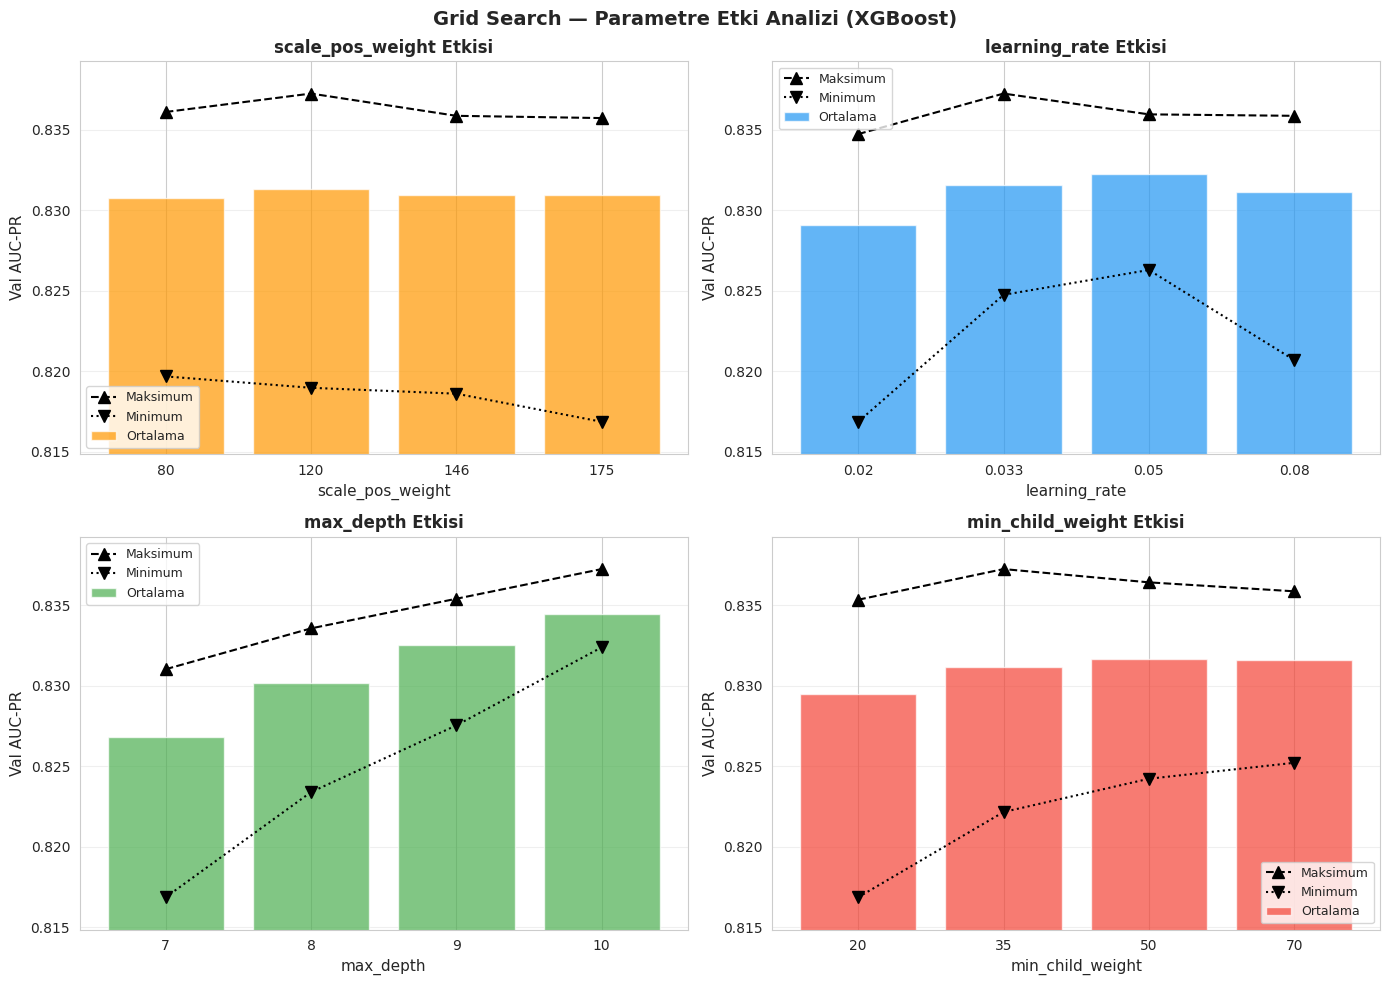

[SURE] Gorsellestirme: 1.8 sn


In [20]:
_t_start = time.time()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#FF9800', '#2196F3', '#4CAF50', '#F44336']

for ax_idx, (key, color) in enumerate(zip(param_keys, colors)):
    ax = axes[ax_idx]
    group = df_results.groupby(key)['val_auc_pr'].agg(['mean', 'max', 'min'])
    x_vals = group.index.tolist()
    x_pos  = range(len(x_vals))

    ax.bar(x_pos, group['mean'], color=color, alpha=0.7, label='Ortalama')
    ax.plot(x_pos, group['max'], 'k^--', markersize=8, label='Maksimum')
    ax.plot(x_pos, group['min'], 'kv:',  markersize=8, label='Minimum')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in x_vals])
    ax.set_xlabel(key, fontsize=11)
    ax.set_ylabel('Val AUC-PR', fontsize=11)
    ax.set_title(f'{key} Etkisi', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(df_results['val_auc_pr'].min() - 0.002,
                df_results['val_auc_pr'].max() + 0.002)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Grid Search — Parametre Etki Analizi (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_BASE + 'xgb_gridsearch_params.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[SURE] Gorsellestirme: {time.time()-_t_start:.1f} sn')

## 21. Final XGBoost — En İyi Grid Search Parametreleriyle Eğitim

Grid Search'ün bulduğu en iyi parametrelerle final model eğitimi.
`n_estimators=3000`, `early_stopping_rounds=100`, `eval_metric='logloss'` — Grid Search ile aynı ayarlar.

In [21]:
_t_start = time.time()

BEST_GS_PARAMS = {
    'scale_pos_weight'     : best_row['scale_pos_weight'],
    'learning_rate'        : best_row['learning_rate'],
    'max_depth'            : int(best_row['max_depth']),
    'min_child_weight'     : int(best_row['min_child_weight']),
    'colsample_bytree'     : FIXED_PARAMS['colsample_bytree'],
    'subsample'            : FIXED_PARAMS['subsample'],
    'reg_alpha'            : FIXED_PARAMS['reg_alpha'],
    'reg_lambda'           : FIXED_PARAMS['reg_lambda'],
    'n_estimators'         : 3000,
    'missing'              : float('nan'),
    'tree_method'          : 'hist',
    'device'               : 'cuda' if USE_GPU else 'cpu',
    'eval_metric'          : 'logloss',   # Grid Search ile tutarli: native XGBoost metrik
    'early_stopping_rounds': 100,
    'random_state'         : 42,
    'n_jobs'               : -1,
    'verbosity'            : 0,
}

print('Final XGBoost egitimi (Grid Search best params)...')
print('Parametreler:')
for k, v in BEST_GS_PARAMS.items():
    print(f'  {k:<25}: {v}')
print()

xgb_model = XGBClassifier(**BEST_GS_PARAMS)
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=200,
)

elapsed_train = time.time() - _t_start
print(f'\nEgitim tamamlandi: {elapsed_train:.0f} sn | best_iteration: {xgb_model.best_iteration}')
print(f'[SURE] Final model egitimi: {elapsed_train:.0f} sn')

Final XGBoost egitimi (Grid Search best params)...
Parametreler:
  scale_pos_weight         : 120.0
  learning_rate            : 0.033
  max_depth                : 10
  min_child_weight         : 35
  colsample_bytree         : 0.8767
  subsample                : 0.9755
  reg_alpha                : 0.001317
  reg_lambda               : 0.2012
  n_estimators             : 3000
  missing                  : nan
  tree_method              : hist
  device                   : cuda
  eval_metric              : logloss
  early_stopping_rounds    : 100
  random_state             : 42
  n_jobs                   : -1
  verbosity                : 0

[0]	validation_0-logloss:1.36441
[200]	validation_0-logloss:0.23332
[400]	validation_0-logloss:0.15339
[600]	validation_0-logloss:0.11892
[800]	validation_0-logloss:0.10177
[1000]	validation_0-logloss:0.09176
[1200]	validation_0-logloss:0.08641
[1400]	validation_0-logloss:0.08288
[1600]	validation_0-logloss:0.08049
[1800]	validation_0-logloss:0.07864
[

## 22. Tahminler ve Metrikler

In [22]:
_t_start = time.time()

val_proba  = xgb_model.predict_proba(X_val)[:, 1]
test_proba = xgb_model.predict_proba(X_test)[:, 1]

val_auc_pr   = average_precision_score(y_val,  val_proba)
test_auc_pr  = average_precision_score(y_test, test_proba)
test_auc_roc = roc_auc_score(y_test, test_proba)

print('=' * 55)
print('  XGBoost Grid Search (NaN Native) — Sonuclar')
print('=' * 55)
print(f'  Val  AUC-PR  : {val_auc_pr:.4f}')
print(f'  Test AUC-PR  : {test_auc_pr:.4f}  (birincil metrik)')
print(f'  Test AUC-ROC : {test_auc_roc:.4f}  (ikincil metrik)')
print(f'  Val-Test gap : {val_auc_pr - test_auc_pr:+.4f}')
print('=' * 55)
print(f'[SURE] Tahmin ve metrik: {time.time()-_t_start:.1f} sn')

  XGBoost Grid Search (NaN Native) — Sonuclar
  Val  AUC-PR  : 0.8372
  Test AUC-PR  : 0.5950  (birincil metrik)
  Test AUC-ROC : 0.9075  (ikincil metrik)
  Val-Test gap : +0.2423
[SURE] Tahmin ve metrik: 11.1 sn


## 23. Eşik Analizi

Operasyonel hedef: **Recall ≥ 0.85** iken mümkün olan en yüksek Precision.

In [23]:
_t_start = time.time()
RECALL_TARGET = 0.85

def f_beta(prec, rec, beta=1.0):
    denom = (beta**2 * prec + rec)
    return (1 + beta**2) * prec * rec / (denom + 1e-10) if denom > 0 else 0.0

sweep_thresholds = sorted(set([
    0.001, 0.002, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05,
    0.07, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40,
    0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80,
    0.85, 0.90, 0.95
]))

rows_thr = []
for t in sweep_thresholds:
    y_pred = (test_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    prec = tp / (tp + fp + 1e-10)
    rec  = tp / (tp + fn + 1e-10)
    rows_thr.append({
        'Esik': t, 'Recall': rec, 'Precision': prec,
        'F1': f_beta(prec, rec, 1.0), 'F2': f_beta(prec, rec, 2.0),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    })

df_thr = pd.DataFrame(rows_thr)

H = f"{'Esik':>6} {'Recall':>7} {'Prec':>7} {'F1':>6} {'F2':>6} {'TP':>5} {'FP':>6} {'FN':>5}"
SEP = '-' * len(H)
print('TEST SETI — ESIK TABLOSU (XGBoost Grid Search, NaN Native)')
print(SEP); print(H); print(SEP)
for _, r in df_thr.iterrows():
    flags = []
    if abs(r['Recall'] - 0.85) < 0.015:   flags.append('R~85')
    if abs(r['Recall'] - 0.80) < 0.015:   flags.append('R~80')
    if abs(r['Precision'] - 0.30) < 0.03: flags.append('P~30')
    flag_str = ' < ' + '+'.join(flags) if flags else ''
    print(f"{r['Esik']:>6.3f} {r['Recall']:>7.4f} {r['Precision']:>7.4f} "
          f"{r['F1']:>6.4f} {r['F2']:>6.4f} "
          f"{int(r['TP']):>5,} {int(r['FP']):>6,} {int(r['FN']):>5,}{flag_str}")
print(SEP)

def find_best_at_recall_ge(target):
    mask = df_thr['Recall'] >= target
    return df_thr[mask].sort_values('Precision', ascending=False).iloc[0] if mask.any() else None

def find_f2_optimal():
    return df_thr.sort_values('F2', ascending=False).iloc[0]

print()
print('KRITIK NOKTALAR:')
print(f'  {"Kisit":<22} {"Esik":>6} {"Recall":>7} {"Prec":>7} {"F2":>6}')
print('  ' + '-' * 52)
for label, r in [
    ('Recall >= 0.85', find_best_at_recall_ge(0.85)),
    ('Recall >= 0.80', find_best_at_recall_ge(0.80)),
    ('F2 Optimal',     find_f2_optimal()),
]:
    if r is None:
        print(f'  {label:<22} — ULASILAMADI')
    else:
        print(f'  {label:<22} {r["Esik"]:>6.3f} {r["Recall"]:>7.4f} {r["Precision"]:>7.4f} {r["F2"]:>6.4f}')

op_row = find_best_at_recall_ge(RECALL_TARGET)
if op_row is not None:
    print()
    print(f'Operasyonel Precision @Recall>=85%: {op_row["Precision"]:.4f}')
print(f'[SURE] Esik analizi: {time.time()-_t_start:.1f} sn')

TEST SETI — ESIK TABLOSU (XGBoost Grid Search, NaN Native)
-------------------------------------------------------
  Esik  Recall    Prec     F1     F2    TP     FP    FN
-------------------------------------------------------
 0.001  0.9301  0.0717 0.1331 0.2739 3,780 48,966   284
 0.002  0.9149  0.0790 0.1454 0.2936 3,718 43,348   346
 0.005  0.8819  0.0951 0.1718 0.3323 3,584 34,085   480
 0.010  0.8553  0.1164 0.2050 0.3769 3,476 26,375   588 < R~85
 0.020  0.8091  0.1480 0.2503 0.4274 3,288 18,923   776 < R~80
 0.030  0.7790  0.1729 0.2830 0.4580 3,166 15,143   898
 0.040  0.7569  0.1949 0.3100 0.4801 3,076 12,706   988
 0.050  0.7409  0.2128 0.3306 0.4951 3,011 11,141 1,053
 0.070  0.7168  0.2442 0.3642 0.5167 2,913  9,018 1,151
 0.100  0.6912  0.2843 0.4028 0.5373 2,809  7,073 1,255 < P~30
 0.150  0.6651  0.3332 0.4440 0.5546 2,703  5,410 1,361
 0.200  0.6476  0.3718 0.4724 0.5639 2,632  4,448 1,432
 0.250  0.6353  0.4052 0.4948 0.5705 2,582  3,790 1,482
 0.300  0.6218  0.4281 0

## 24. Precision-Recall Eğrisi

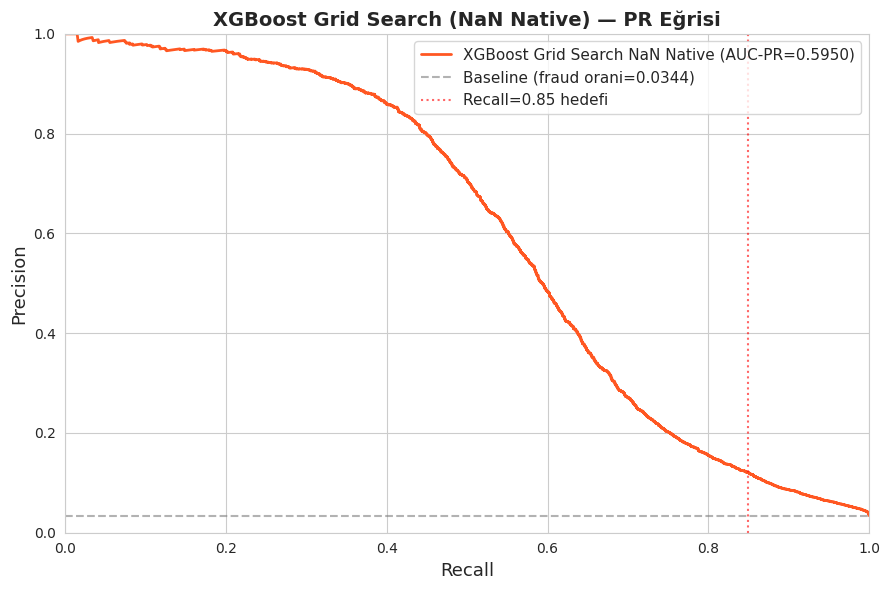

[SURE] PR egrisi: 1.3 sn


In [24]:
_t_start = time.time()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_proba)
baseline_pr = y_test.mean()

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(recall_curve, precision_curve, lw=2, color='#FF5722',
        label=f'XGBoost Grid Search NaN Native (AUC-PR={test_auc_pr:.4f})')
ax.axhline(y=baseline_pr, color='gray', linestyle='--', alpha=0.6,
           label=f'Baseline (fraud orani={baseline_pr:.4f})')
ax.axvline(x=0.85, color='red', linestyle=':', alpha=0.6, label='Recall=0.85 hedefi')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('XGBoost Grid Search (NaN Native) — PR Eğrisi', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig(SAVE_BASE + 'xgb_gridsearch_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[SURE] PR egrisi: {time.time()-_t_start:.1f} sn')

## 25. Özellik Önemi (Top 30)

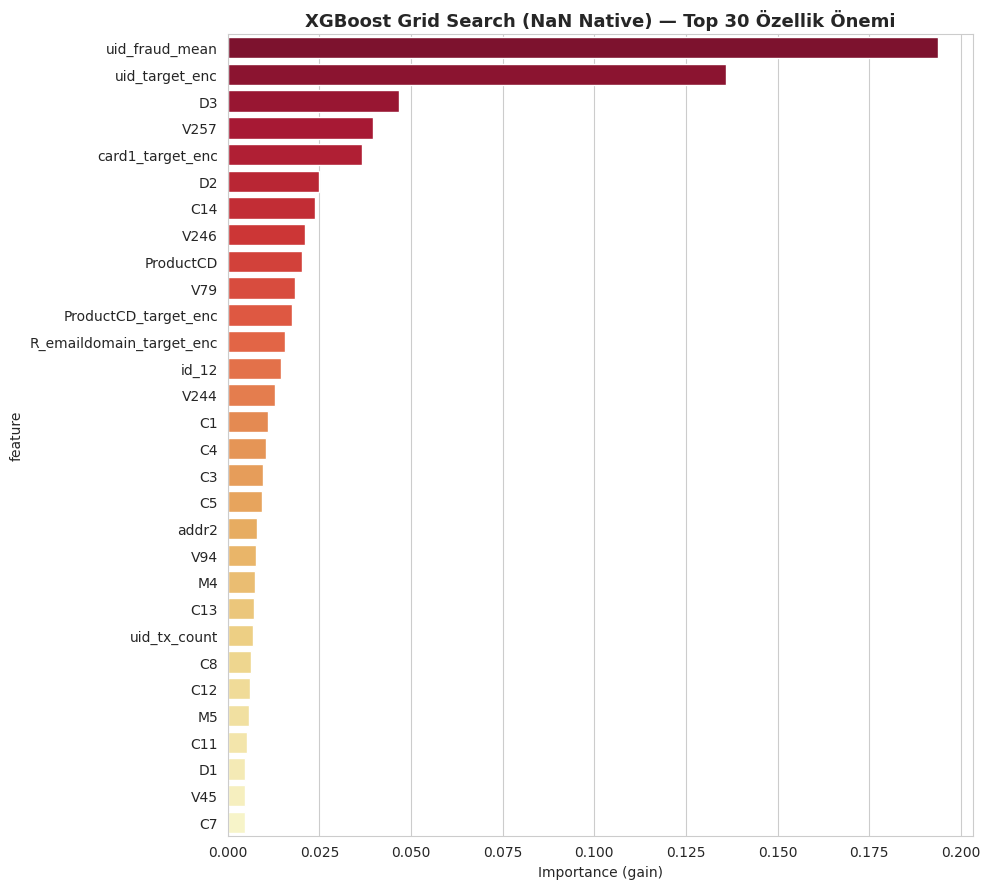

[SURE] Ozellik onemi: 0.5 sn


In [25]:
_t_start = time.time()

feat_imp = pd.DataFrame({
    'feature'   : X_tr.columns.tolist(),
    'importance': xgb_model.feature_importances_,
}).sort_values('importance', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='YlOrRd_r', ax=ax)
ax.set_title('XGBoost Grid Search (NaN Native) — Top 30 Özellik Önemi', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()
print(f'[SURE] Ozellik onemi: {time.time()-_t_start:.1f} sn')

## 26. Model ve Veri Kaydı — Drive'a Kaydetme

Tüm çıktılar `SAVE_BASE` klasörüne kaydedilir.
Özet veri kaydı (`xgb_gridsearch_record.csv`) her koşuda üzerine yazılır.

In [26]:
_t_start = time.time()

import joblib, datetime

os.makedirs(SAVE_BASE, exist_ok=True)

# Model kaydet
joblib.dump(xgb_model, SAVE_BASE + 'xgb_gridsearch_model.pkl')
print('  xgb_gridsearch_model.pkl kaydedildi.')

# Tam grid sonuçlarını CSV olarak kaydet
df_results.to_csv(SAVE_BASE + 'xgb_gridsearch_results.csv', index=False)
print('  xgb_gridsearch_results.csv kaydedildi.')

# Threshold tablosunu kaydet
df_thr.to_csv(SAVE_BASE + 'xgb_gridsearch_threshold_table.csv', index=False)
print('  xgb_gridsearch_threshold_table.csv kaydedildi.')

# ── Özet veri kaydı ───────────────────────────────────────────────────────────
record = {
    'tarih'             : datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
    'model'             : 'XGBoost',
    'yontem'            : 'Grid Search (256 combo)',
    'nan_stratejisi'    : 'NaN Native (missing=nan)',
    'eval_metric'       : 'logloss',
    'n_combos'          : N_COMBOS,
    'gridsearch_sure_dk': round(elapsed_grid / 60, 1),
    'best_iteration'    : xgb_model.best_iteration,
    'val_auc_pr'        : round(val_auc_pr, 4),
    'test_auc_pr'       : round(test_auc_pr, 4),
    'test_auc_roc'      : round(test_auc_roc, 4),
    'prec_at_recall85'  : round(op_row['Precision'], 4) if op_row is not None else None,
    'recall_at_recall85': round(op_row['Recall'],    4) if op_row is not None else None,
    'val_test_gap'      : round(val_auc_pr - test_auc_pr, 4),
    'best_scale_pos_weight' : best_row['scale_pos_weight'],
    'best_learning_rate'    : best_row['learning_rate'],
    'best_max_depth'        : int(best_row['max_depth']),
    'best_min_child_weight' : int(best_row['min_child_weight']),
}

df_record = pd.DataFrame([record])
record_path = SAVE_BASE + 'xgb_gridsearch_record.csv'
df_record.to_csv(record_path, index=False)
print('  xgb_gridsearch_record.csv kaydedildi.')
print()
print('=== VERİ KAYDI ===')
for k, v in record.items():
    print(f'  {k:<30}: {v}')

print(f'[SURE] Model ve veri kaydetme: {time.time()-_t_start:.1f} sn')

  xgb_gridsearch_model.pkl kaydedildi.
  xgb_gridsearch_results.csv kaydedildi.
  xgb_gridsearch_threshold_table.csv kaydedildi.
  xgb_gridsearch_record.csv kaydedildi.

=== VERİ KAYDI ===
  tarih                         : 2026-05-11 21:38
  model                         : XGBoost
  yontem                        : Grid Search (256 combo)
  nan_stratejisi                : NaN Native (missing=nan)
  eval_metric                   : logloss
  n_combos                      : 256
  gridsearch_sure_dk            : 299.8
  best_iteration                : 2963
  val_auc_pr                    : 0.8372
  test_auc_pr                   : 0.595
  test_auc_roc                  : 0.9075
  prec_at_recall85              : 0.1164
  recall_at_recall85            : 0.8553
  val_test_gap                  : 0.2423
  best_scale_pos_weight         : 120.0
  best_learning_rate            : 0.033
  best_max_depth                : 10
  best_min_child_weight         : 35
[SURE] Model ve veri kaydetme: 0.2 sn


## 27. Deney Özeti ve Optuna Karşılaştırması

In [27]:
total_elapsed = time.time() - _t0_total

print('=' * 65)
print('  DENEY ÖZETİ — XGBoost Grid Search (NaN Native)')
print('=' * 65)
print(f'  Model              : XGBoost (hist, NaN Native)')
print(f'  Yontem             : Grid Search (256 kombinasyon)')
print(f'  eval_metric (stop) : logloss — XGBoost native, istikrarli')
print(f'  Grid sure          : {elapsed_grid/60:.1f} dakika (kumulatif)')
print()
print(f'  En iyi Val AUC-PR  : {best_row["val_auc_pr"]:.4f}')
print()
print(f'  En iyi parametreler:')
for k in param_keys:
    print(f'    {k:<25}: {best_row[k]}')
print(f'    {"best_iteration":<25}: {xgb_model.best_iteration}')
print()
print(f'  Test AUC-PR        : {test_auc_pr:.4f}  <- birincil metrik')
print(f'  Test AUC-ROC       : {test_auc_roc:.4f}')
if op_row is not None:
    print(f'  Prec @Recall>=85%  : {op_row["Precision"]:.4f}')
print()
print(f'  Toplam sure        : {total_elapsed/60:.1f} dakika ({total_elapsed:.0f} sn)')
print('=' * 65)

  DENEY ÖZETİ — XGBoost Grid Search (NaN Native)
  Model              : XGBoost (hist, NaN Native)
  Yontem             : Grid Search (256 kombinasyon)
  eval_metric (stop) : logloss — XGBoost native, istikrarli
  Grid sure          : 299.8 dakika (kumulatif)

  En iyi Val AUC-PR  : 0.8372

  En iyi parametreler:
    scale_pos_weight         : 120.0
    learning_rate            : 0.033
    max_depth                : 10.0
    min_child_weight         : 35.0
    best_iteration           : 2963

  Test AUC-PR        : 0.5950  <- birincil metrik
  Test AUC-ROC       : 0.9075
  Prec @Recall>=85%  : 0.1164

  Toplam sure        : 55.6 dakika (3337 sn)
